# Study 1 — Haptic vs Midair Condition Analysis

This notebook loads all `*_Summary.csv` files from the `haptic/` and `midair/` folders, then analyzes and visualizes **Error (mm)**, **CompletionTime (s)**, and **NLM** across the two conditions.

In [81]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from scipy import stats

matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.size'] = 12

# ---------- data loading ----------
BASE_DIR = os.path.dirname(os.path.abspath('__file__'))  # notebook dir

conditions = ['haptic', 'midair']
all_dfs = []

for cond in conditions:
    folder = os.path.join(BASE_DIR, cond)
    csv_files = sorted(glob.glob(os.path.join(folder, '*_Summary.csv')))
    for uid, fpath in enumerate(csv_files, start=1):
        df = pd.read_csv(fpath)
        df['ParticipantID'] = uid
        df['Condition'] = cond
        all_dfs.append(df)

data = pd.concat(all_dfs, ignore_index=True)
print(f'Total rows: {len(data)}  |  Conditions: {data.Condition.unique()}')
print(f'Participants per condition: {data.groupby("Condition")["ParticipantID"].nunique().to_dict()}')
data.head()

Total rows: 1260  |  Conditions: ['haptic' 'midair']
Participants per condition: {'haptic': 7, 'midair': 7}


,UserID,ExpID,TrialNumber,Condition,StartHeight(mm),TargetHeight(mm),FinalHeight(mm),Error(mm),CompletionTime(s),ParticipantID
0,1,Exp_20260316_183514,1,haptic,0.0,10.0,12.32,2.32,0.966,1
1,1,Exp_20260316_183514,2,haptic,40.0,50.0,52.48,2.48,1.300,1
2,1,Exp_20260316_183514,3,haptic,50.0,20.0,19.72,0.28,1.599,1
3,1,Exp_20260316_183514,4,haptic,20.0,0.0,3.44,3.44,0.610,1
4,1,Exp_20260316_183514,5,haptic,50.0,30.0,33.55,3.55,0.589,1


## 1. Descriptive Statistics

In [82]:
desc = data.groupby('Condition')[['Error(mm)', 'CompletionTime(s)']].agg(['mean', 'std', 'median', 'min', 'max'])
desc

Error(mm)                             CompletionTime(s)            \
               mean       std median  min   max              mean       std   
Condition                                                                     
haptic     1.287127  1.279579  0.975  0.0  9.10          1.478422  0.818221   
midair     1.137270  1.025007  0.930  0.0  9.12          0.873246  0.330778   

                                 
           median    min    max  
Condition                        
haptic     1.3325  0.312  6.486  
midair     0.8220  0.186  4.142

## 2. Per-participant Mean (for statistical tests)

In [83]:
per_participant = data.groupby(['Condition', 'ParticipantID'])[['Error(mm)', 'CompletionTime(s)']].mean().reset_index()
per_participant

,Condition,ParticipantID,Error(mm),CompletionTime(s)
0,haptic,1,1.484444,1.277478
1,haptic,2,1.981444,1.153422
2,haptic,3,2.054111,0.932856
3,haptic,4,0.778333,1.488500
4,haptic,5,0.917667,1.996033
5,haptic,6,0.733000,2.056667
6,haptic,7,1.060889,1.444000
7,midair,1,1.174333,0.791822
8,midair,2,1.235556,0.818989
9,midair,3,1.667222,0.715611


## 3. Significance Testing (Error & CompletionTime)

Pipeline: **Shapiro-Wilk normality check → Independent t-test / Mann-Whitney U → Cohen’s d**

In [84]:
def cohens_d(g1, g2):
    """Compute Cohen's d for two independent groups."""
    n1, n2 = len(g1), len(g2)
    var1, var2 = g1.var(ddof=1), g2.var(ddof=1)
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return (g1.mean() - g2.mean()) / pooled_std

def run_significance_test(per_part_df, var, label):
    """Run full significance pipeline on one variable, return result dict."""
    h = per_part_df.loc[per_part_df.Condition == 'haptic', var].values
    m = per_part_df.loc[per_part_df.Condition == 'midair', var].values

    sw_h_stat, sw_h_p = stats.shapiro(h)
    sw_m_stat, sw_m_p = stats.shapiro(m)
    both_normal = (sw_h_p > 0.05) and (sw_m_p > 0.05)

    if both_normal:
        _, lev_p = stats.levene(h, m)
        equal_var = lev_p > 0.05
        t_stat, t_p = stats.ttest_ind(h, m, equal_var=equal_var)
        test_name = 'Independent t-test' + ('' if equal_var else ' (Welch)')
        test_stat, test_p = t_stat, t_p
    else:
        u_stat, u_p = stats.mannwhitneyu(h, m, alternative='two-sided')
        test_name = 'Mann-Whitney U'
        test_stat, test_p = u_stat, u_p

    d = cohens_d(pd.Series(h), pd.Series(m))
    sig = '***' if test_p < 0.001 else '**' if test_p < 0.01 else '*' if test_p < 0.05 else 'n.s.'

    print(f'\n===== {label} =====')
    print(f'  Haptic  : M = {h.mean():.4f}, SD = {h.std(ddof=1):.4f}')
    print(f'  Midair  : M = {m.mean():.4f}, SD = {m.std(ddof=1):.4f}')
    print(f'  Shapiro-Wilk  haptic p = {sw_h_p:.4f}  midair p = {sw_m_p:.4f}  -> {"Normal" if both_normal else "Non-normal"}')
    print(f'  {test_name}: stat = {test_stat:.4f},  p = {test_p:.4f}  {sig}')
    print(f"  Cohen's d = {d:.4f}")

    return {
        'Variable': label,
        'Haptic (M\u00b1SD)': f'{h.mean():.3f} \u00b1 {h.std(ddof=1):.3f}',
        'Midair (M\u00b1SD)': f'{m.mean():.3f} \u00b1 {m.std(ddof=1):.3f}',
        'Test': test_name,
        'Statistic': f'{test_stat:.4f}',
        'p-value': f'{test_p:.4f}',
        'Sig.': sig,
        "Cohen's d": f'{d:.4f}',
    }

results = []
for var, label in [('Error(mm)', 'Error (mm)'), ('CompletionTime(s)', 'CompletionTime (s)')]:
    results.append(run_significance_test(per_participant, var, label))

pd.DataFrame(results)


===== Error (mm) =====
  Haptic  : M = 1.2871, SD = 0.5572
  Midair  : M = 1.1373, SD = 0.2804
  Shapiro-Wilk  haptic p = 0.1602  midair p = 0.2840  -> Normal
  Independent t-test: stat = 0.6356,  p = 0.5370  n.s.
  Cohen's d = 0.3397

===== CompletionTime (s) =====
  Haptic  : M = 1.4784, SD = 0.4178
  Midair  : M = 0.8732, SD = 0.1204
  Shapiro-Wilk  haptic p = 0.5270  midair p = 0.6075  -> Normal
  Independent t-test: stat = 3.6828,  p = 0.0031  **
  Cohen's d = 1.9685


,Variable,Haptic (M±SD),Midair (M±SD),Test,Statistic,p-value,Sig.,Cohen's d
0,Error (mm),1.287 ± 0.557,1.137 ± 0.280,Independent t-test,0.6356,0.5370,n.s.,0.3397
1,CompletionTime (s),1.478 ± 0.418,0.873 ± 0.120,Independent t-test,3.6828,0.0031,**,1.9685


## 4. Visualization (Error & CompletionTime)

### 4.1 Bar Chart with Error Bars (Mean ± SE per condition)

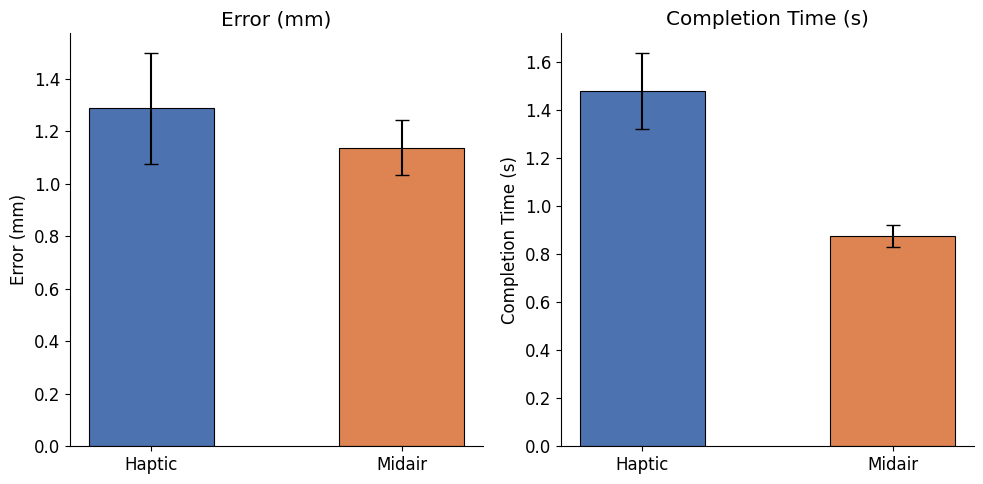

In [85]:
COLORS = {'haptic': '#4C72B0', 'midair': '#DD8452'}

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, var, ylabel in zip(axes, ['Error(mm)', 'CompletionTime(s)'], ['Error (mm)', 'Completion Time (s)']):
    means = per_participant.groupby('Condition')[var].mean()
    sems  = per_participant.groupby('Condition')[var].sem()
    x = range(len(conditions))
    bars = ax.bar(x, [means[c] for c in conditions],
                  yerr=[sems[c] for c in conditions],
                  color=[COLORS[c] for c in conditions],
                  capsize=5, edgecolor='black', linewidth=0.8, width=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels([c.capitalize() for c in conditions])
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'bar_chart.png'), dpi=150, bbox_inches='tight')
plt.show()

### 4.2 Box Plot

C:\Users\32785\AppData\Local\Temp\ipykernel_31672\3300507785.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=[c.capitalize() for c in conditions],
C:\Users\32785\AppData\Local\Temp\ipykernel_31672\3300507785.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=[c.capitalize() for c in conditions],


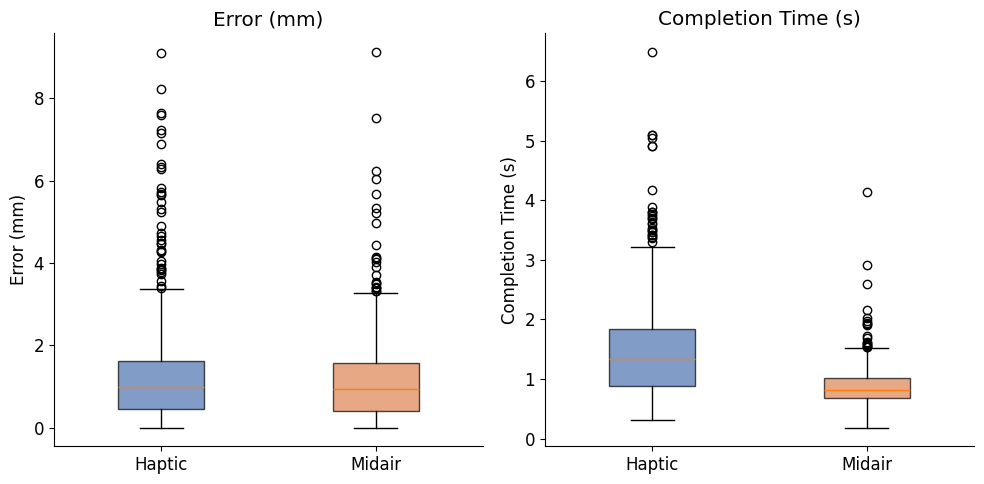

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, var, ylabel in zip(axes, ['Error(mm)', 'CompletionTime(s)'], ['Error (mm)', 'Completion Time (s)']):
    box_data = [data.loc[data.Condition == c, var].values for c in conditions]
    bp = ax.boxplot(box_data, labels=[c.capitalize() for c in conditions],
                    patch_artist=True, widths=0.4, showfliers=True)
    for patch, c in zip(bp['boxes'], conditions):
        patch.set_facecolor(COLORS[c])
        patch.set_alpha(0.7)
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'box_plot.png'), dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Violin Plot with Strip (Individual Trials)

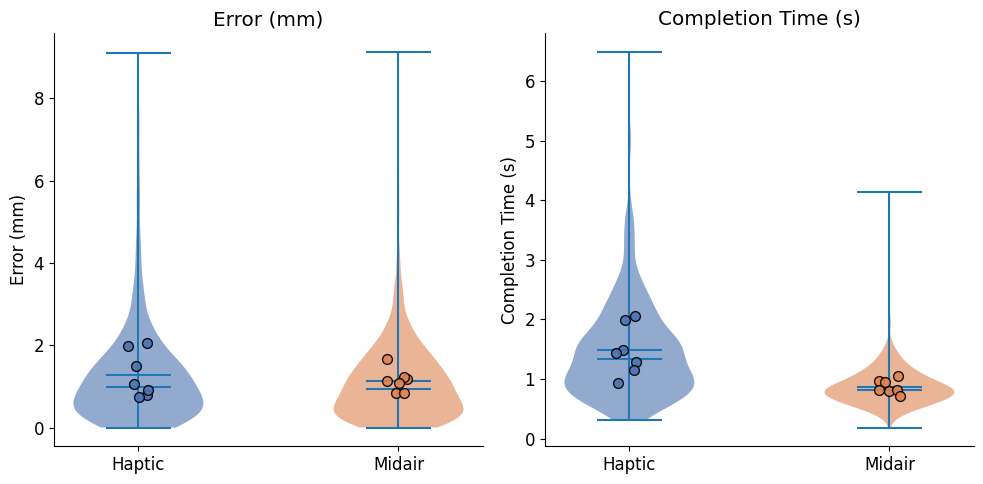

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, var, ylabel in zip(axes, ['Error(mm)', 'CompletionTime(s)'], ['Error (mm)', 'Completion Time (s)']):
    parts = ax.violinplot(
        [data.loc[data.Condition == c, var].values for c in conditions],
        positions=[0, 1], showmeans=True, showmedians=True)
    for i, (body, c) in enumerate(zip(parts['bodies'], conditions)):
        body.set_facecolor(COLORS[c])
        body.set_alpha(0.6)
    for i, c in enumerate(conditions):
        vals = per_participant.loc[per_participant.Condition == c, var]
        ax.scatter(np.full(len(vals), i) + np.random.uniform(-0.05, 0.05, len(vals)),
                   vals, color=COLORS[c], edgecolor='black', s=50, zorder=3, alpha=0.9)
    ax.set_xticks([0, 1])
    ax.set_xticklabels([c.capitalize() for c in conditions])
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'violin_plot.png'), dpi=150, bbox_inches='tight')
plt.show()

### 4.4 Per-Participant Mean Comparison (Grouped Bar)

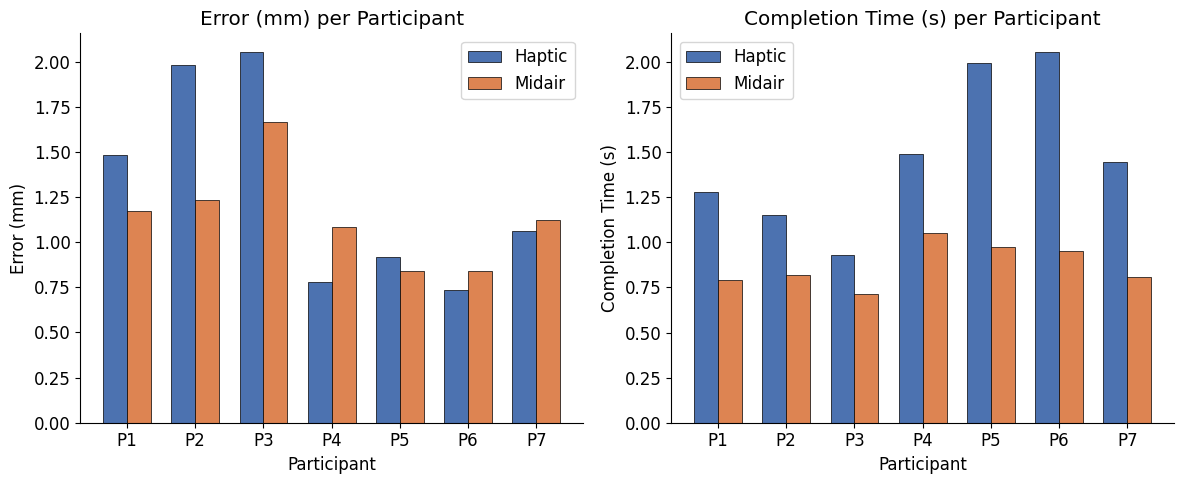

In [88]:
n_participants = per_participant.ParticipantID.nunique()
x = np.arange(n_participants)
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, var, ylabel in zip(axes, ['Error(mm)', 'CompletionTime(s)'], ['Error (mm)', 'Completion Time (s)']):
    haptic_means = per_participant.loc[per_participant.Condition == 'haptic', var].values
    midair_means = per_participant.loc[per_participant.Condition == 'midair', var].values
    ax.bar(x - width/2, haptic_means, width, label='Haptic', color=COLORS['haptic'], edgecolor='black', linewidth=0.5)
    ax.bar(x + width/2, midair_means, width, label='Midair', color=COLORS['midair'], edgecolor='black', linewidth=0.5)
    ax.set_xlabel('Participant')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel} per Participant')
    ax.set_xticks(x)
    ax.set_xticklabels([f'P{i+1}' for i in x])
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'per_participant.png'), dpi=150, bbox_inches='tight')
plt.show()

### 4.5 Trial-level Trend (Mean ± SE across participants)

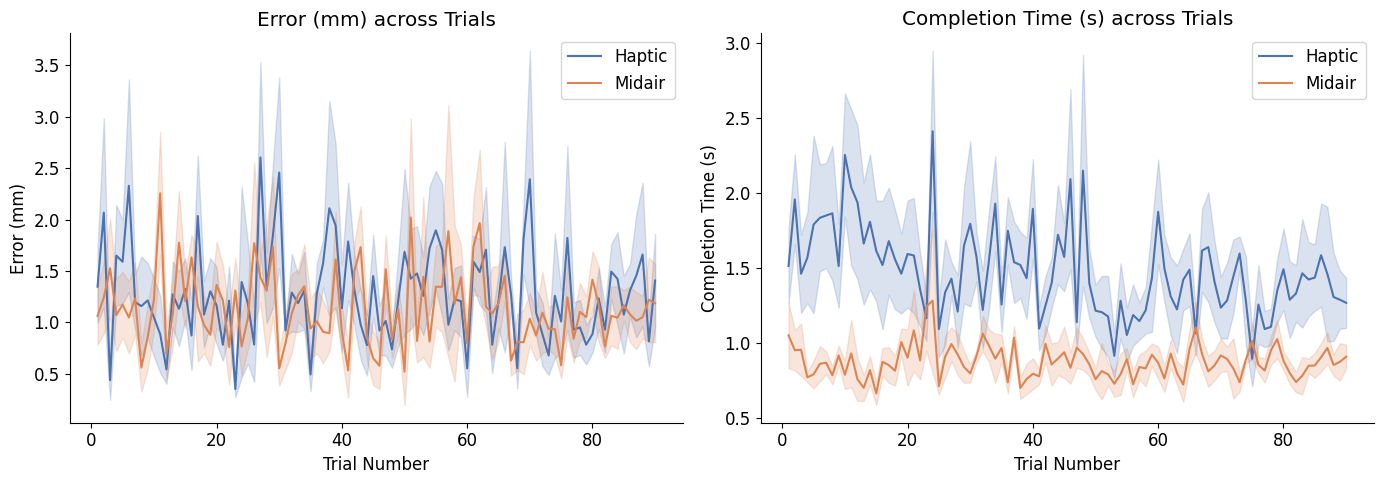

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, var, ylabel in zip(axes, ['Error(mm)', 'CompletionTime(s)'], ['Error (mm)', 'Completion Time (s)']):
    for c in conditions:
        subset = data[data.Condition == c]
        trial_stats = subset.groupby('TrialNumber')[var].agg(['mean', 'sem'])
        ax.plot(trial_stats.index, trial_stats['mean'], label=c.capitalize(), color=COLORS[c], linewidth=1.5)
        ax.fill_between(trial_stats.index,
                        trial_stats['mean'] - trial_stats['sem'],
                        trial_stats['mean'] + trial_stats['sem'],
                        color=COLORS[c], alpha=0.2)
    ax.set_xlabel('Trial Number')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel} across Trials')
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'trial_trend.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 5. NLM (Number of Local Maxima) Computation

NLM counts local peaks in the `DistanceToTarget(mm)` time-series per trial.  
Each peak represents a corrective action by the user. Higher NLM = more oscillation = less stable.

In [92]:
def calculate_nlm(error_sequence):
    """Calculate NLM with IQR-based outlier removal."""
    seq = np.asarray(error_sequence, dtype=float)
    # IQR outlier removal
    q1, q3 = np.percentile(seq, [25, 75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    filtered = seq[(seq >= lower) & (seq <= upper)]
    # Count local maxima
    if len(filtered) < 3:
        return 0
    count = 0
    for i in range(1, len(filtered) - 1):
        if filtered[i] > filtered[i - 1] and filtered[i] > filtered[i + 1]:
            count += 1
    return count    
    
    # if len(seq) < 3:
    #     return 0
    # count = 0
    # for i in range(1, len(seq) - 1):
    #     if seq[i] > seq[i - 1] and seq[i] > seq[i + 1]:
    #         count += 1
    # return count

# ---------- load all Continuous CSVs ----------
cont_dfs = []
for cond in conditions:
    folder = os.path.join(BASE_DIR, cond)
    csv_files = sorted(glob.glob(os.path.join(folder, '*_Continuous.csv')))
    for uid, fpath in enumerate(csv_files, start=1):
        df = pd.read_csv(fpath)
        df['ParticipantID'] = uid
        df['Condition'] = cond
        cont_dfs.append(df)

cont_data = pd.concat(cont_dfs, ignore_index=True)
print(f'Continuous data loaded: {len(cont_data)} rows')

# ---------- compute NLM per trial ----------
nlm_records = []
for (cond, pid, trial), grp in cont_data.groupby(['Condition', 'ParticipantID', 'TrialNumber']):
    error_seq = grp['DistanceToTarget(mm)'].values
    nlm = calculate_nlm(error_seq)
    nlm_records.append({'Condition': cond, 'ParticipantID': pid, 'TrialNumber': trial, 'NLM': nlm})

nlm_data = pd.DataFrame(nlm_records)
print(f'NLM computed for {len(nlm_data)} trials')
nlm_data.head(10)

Continuous data loaded: 117509 rows
NLM computed for 1260 trials


,Condition,ParticipantID,TrialNumber,NLM
0,haptic,1,1,3
1,haptic,1,2,2
2,haptic,1,3,3
3,haptic,1,4,1
4,haptic,1,5,1
5,haptic,1,6,7
6,haptic,1,7,4
7,haptic,1,8,5
8,haptic,1,9,5
9,haptic,1,10,7


In [93]:
# Per-participant mean NLM
nlm_per_participant = nlm_data.groupby(['Condition', 'ParticipantID'])['NLM'].mean().reset_index()
print('Per-participant mean NLM:')
nlm_per_participant

Per-participant mean NLM:


,Condition,ParticipantID,NLM
0,haptic,1,4.144444
1,haptic,2,3.922222
2,haptic,3,2.500000
3,haptic,4,5.088889
4,haptic,5,9.022222
5,haptic,6,14.177778
6,haptic,7,5.000000
7,midair,1,4.444444
8,midair,2,2.333333
9,midair,3,4.366667


## 6. NLM Significance Testing

Same pipeline: **Shapiro-Wilk → t-test / Mann-Whitney U → Cohen’s d**

In [94]:
nlm_result = run_significance_test(nlm_per_participant, 'NLM', 'NLM')
pd.DataFrame([nlm_result])


===== NLM =====
  Haptic  : M = 6.2651, SD = 4.0282
  Midair  : M = 4.2175, SD = 2.1149
  Shapiro-Wilk  haptic p = 0.0697  midair p = 0.7775  -> Normal
  Independent t-test: stat = 1.1908,  p = 0.2568  n.s.
  Cohen's d = 0.6365


,Variable,Haptic (M±SD),Midair (M±SD),Test,Statistic,p-value,Sig.,Cohen's d
0,NLM,6.265 ± 4.028,4.217 ± 2.115,Independent t-test,1.1908,0.2568,n.s.,0.6365


## 7. NLM Visualization

### 7.1 NLM Bar Chart (Mean ± SE)

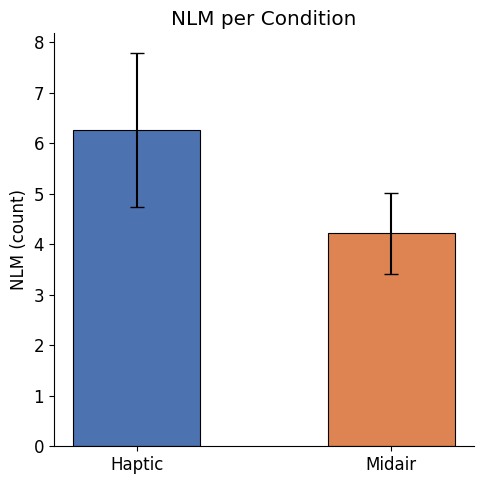

In [95]:
fig, ax = plt.subplots(figsize=(5, 5))
means = nlm_per_participant.groupby('Condition')['NLM'].mean()
sems  = nlm_per_participant.groupby('Condition')['NLM'].sem()
x = range(len(conditions))
ax.bar(x, [means[c] for c in conditions],
       yerr=[sems[c] for c in conditions],
       color=[COLORS[c] for c in conditions],
       capsize=5, edgecolor='black', linewidth=0.8, width=0.5)
ax.set_xticks(x)
ax.set_xticklabels([c.capitalize() for c in conditions])
ax.set_ylabel('NLM (count)')
ax.set_title('NLM per Condition')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'nlm_bar.png'), dpi=150, bbox_inches='tight')
plt.show()

### 7.2 NLM Box Plot

C:\Users\32785\AppData\Local\Temp\ipykernel_31672\290241084.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=[c.capitalize() for c in conditions],


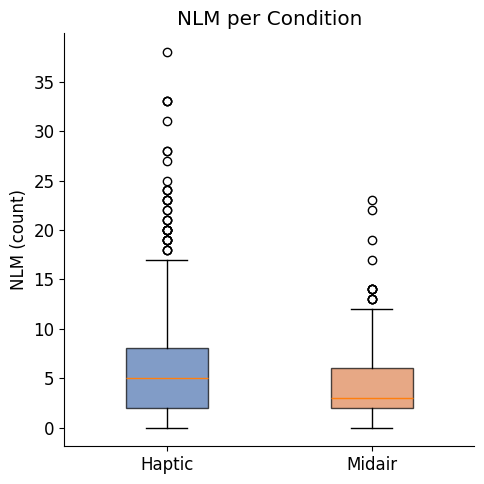

In [96]:
fig, ax = plt.subplots(figsize=(5, 5))
box_data = [nlm_data.loc[nlm_data.Condition == c, 'NLM'].values for c in conditions]
bp = ax.boxplot(box_data, labels=[c.capitalize() for c in conditions],
                patch_artist=True, widths=0.4, showfliers=True)
for patch, c in zip(bp['boxes'], conditions):
    patch.set_facecolor(COLORS[c])
    patch.set_alpha(0.7)
ax.set_ylabel('NLM (count)')
ax.set_title('NLM per Condition')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'nlm_box.png'), dpi=150, bbox_inches='tight')
plt.show()

### 7.3 NLM Violin Plot with Per-Participant Dots

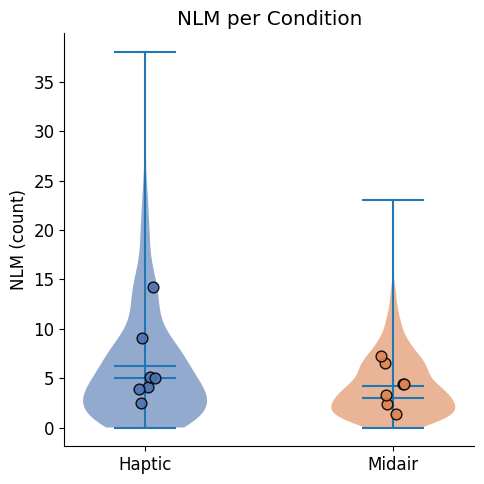

In [97]:
fig, ax = plt.subplots(figsize=(5, 5))
parts = ax.violinplot(
    [nlm_data.loc[nlm_data.Condition == c, 'NLM'].values for c in conditions],
    positions=[0, 1], showmeans=True, showmedians=True)
for body, c in zip(parts['bodies'], conditions):
    body.set_facecolor(COLORS[c])
    body.set_alpha(0.6)
for i, c in enumerate(conditions):
    vals = nlm_per_participant.loc[nlm_per_participant.Condition == c, 'NLM']
    ax.scatter(np.full(len(vals), i) + np.random.uniform(-0.05, 0.05, len(vals)),
               vals, color=COLORS[c], edgecolor='black', s=60, zorder=3, alpha=0.9)
ax.set_xticks([0, 1])
ax.set_xticklabels([c.capitalize() for c in conditions])
ax.set_ylabel('NLM (count)')
ax.set_title('NLM per Condition')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'nlm_violin.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Trajectory Visualization (Distance-to-Target vs Time)

Use `plot_trajectory()` to visualize how the distance to target changes over time for selected trials.  
You can plot a single trial, multiple trials, or compare across conditions.

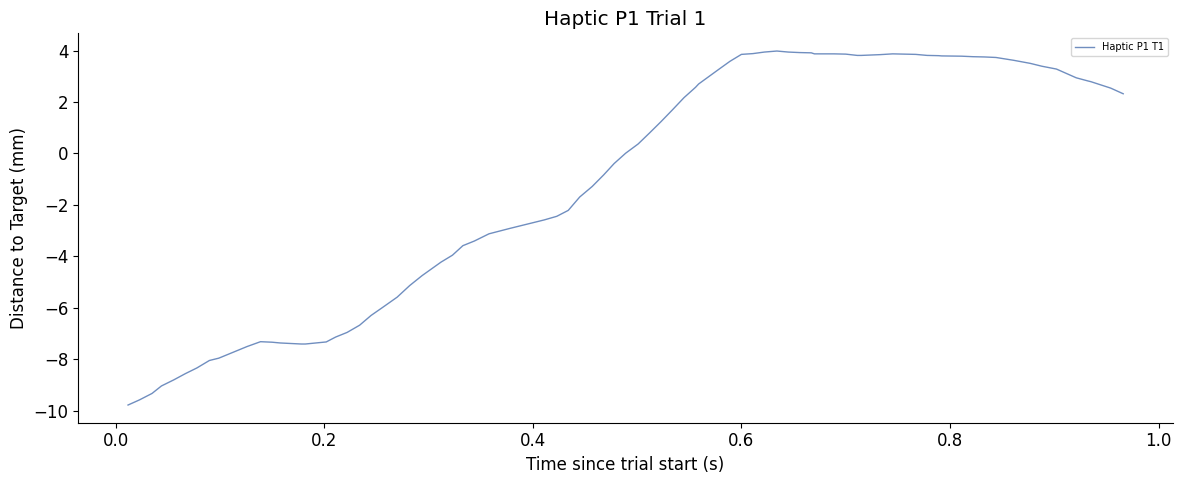

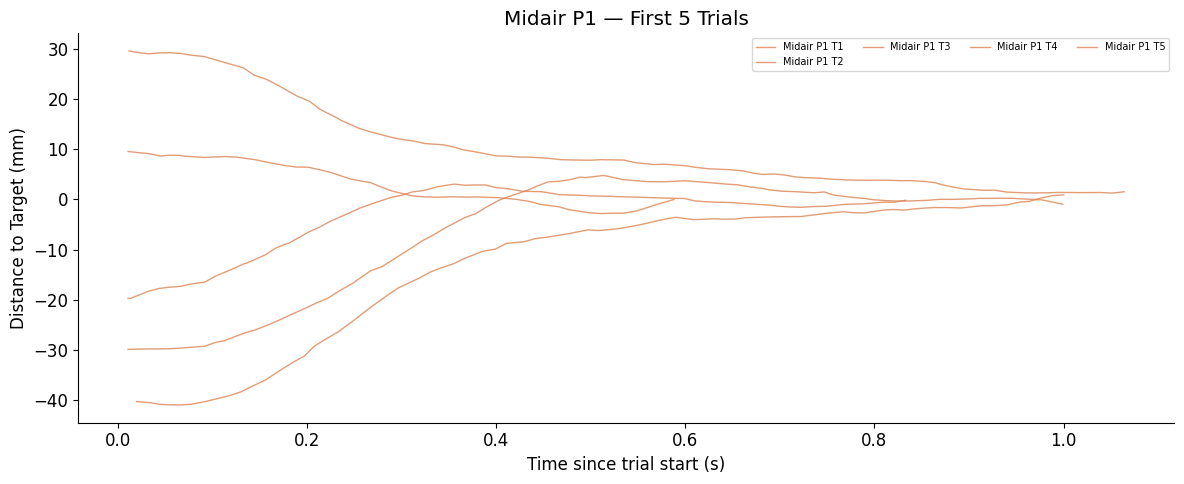

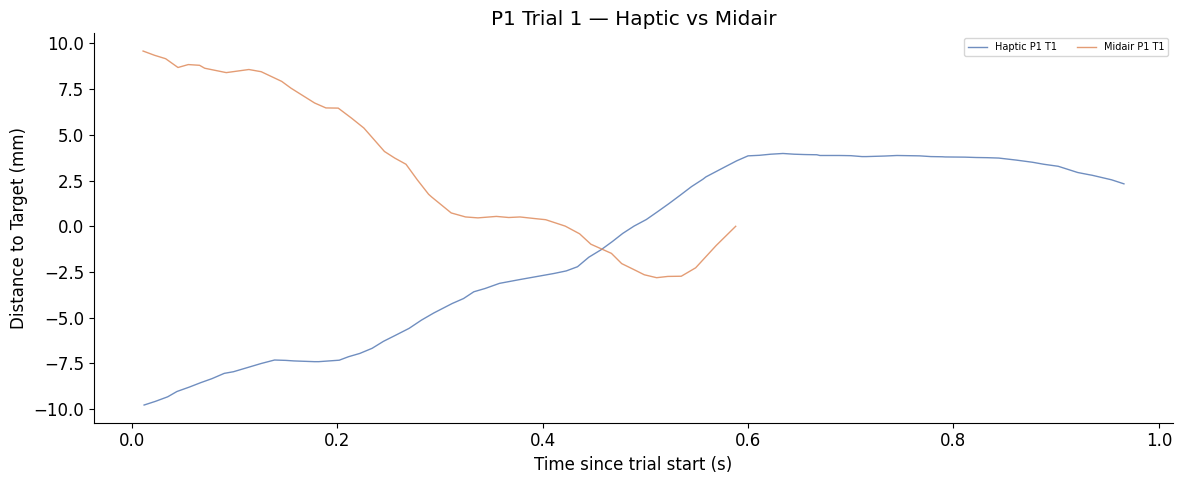

In [98]:
def plot_trajectory(condition=None, participant_id=None, trial_numbers=None,
                    figsize=(12, 5), alpha=0.8, title=None):
    """
    Plot DistanceToTarget(mm) vs TimeSinceTrialStart(s) for selected trajectories.

    Parameters
    ----------
    condition : str or list of str, optional
        'haptic', 'midair', or ['haptic', 'midair']. None = both.
    participant_id : int or list of int, optional
        Participant ID(s). None = all participants.
    trial_numbers : int or list of int, optional
        Trial number(s) to plot. None = all trials.
    figsize : tuple
        Figure size.
    alpha : float
        Line transparency.
    title : str, optional
        Custom plot title.
    """
    subset = cont_data.copy()

    # --- filter ---
    if condition is not None:
        if isinstance(condition, str):
            condition = [condition]
        subset = subset[subset['Condition'].isin(condition)]
    if participant_id is not None:
        if isinstance(participant_id, (int, np.integer)):
            participant_id = [participant_id]
        subset = subset[subset['ParticipantID'].isin(participant_id)]
    if trial_numbers is not None:
        if isinstance(trial_numbers, (int, np.integer)):
            trial_numbers = [trial_numbers]
        subset = subset[subset['TrialNumber'].isin(trial_numbers)]

    if subset.empty:
        print('No data matches the given filters.')
        return

    fig, ax = plt.subplots(figsize=figsize)
    groups = subset.groupby(['Condition', 'ParticipantID', 'TrialNumber'])
    n_groups = len(groups)
    cmap = plt.cm.tab10 if n_groups <= 10 else plt.cm.tab20

    for idx, ((cond, pid, trial), grp) in enumerate(groups):
        color = COLORS.get(cond, cmap(idx / max(n_groups - 1, 1)))
        label = f'{cond.capitalize()} P{pid} T{trial}'
        ax.plot(grp['TimeSinceTrialStart(s)'].values,
                grp['DistanceToTarget(mm)'].values,
                color=color, alpha=alpha, linewidth=1, label=label)

    ax.set_xlabel('Time since trial start (s)')
    ax.set_ylabel('Distance to Target (mm)')
    if title:
        ax.set_title(title)
    else:
        ax.set_title(f'Trajectory ({n_groups} trial{"s" if n_groups != 1 else ""})')
    ax.spines[['top', 'right']].set_visible(False)

    # show legend only when <= 20 lines
    if n_groups <= 20:
        ax.legend(fontsize=7, loc='upper right', ncol=min(n_groups, 4))
    plt.tight_layout()
    plt.show()

# ---------- Example usage ----------
# Single trial
plot_trajectory(condition='haptic', participant_id=1, trial_numbers=1,
                title='Haptic P1 Trial 1')

# Multiple trials for one participant (compare across trials)
plot_trajectory(condition='midair', participant_id=1, trial_numbers=[1, 2, 3, 4, 5],
                title='Midair P1 — First 5 Trials')

# Compare same trial across conditions
plot_trajectory(condition=['haptic', 'midair'], participant_id=1, trial_numbers=1,
                title='P1 Trial 1 — Haptic vs Midair')

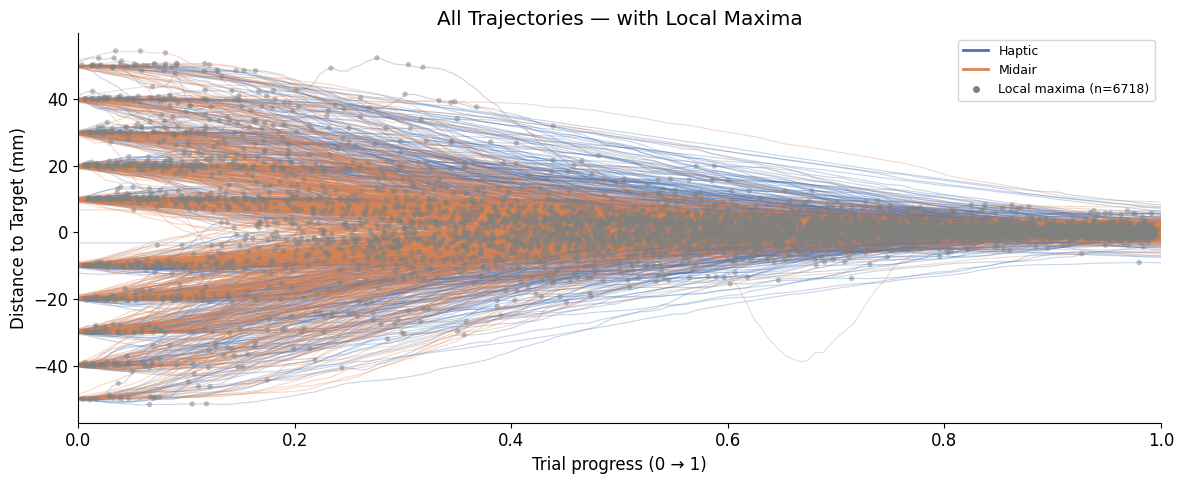

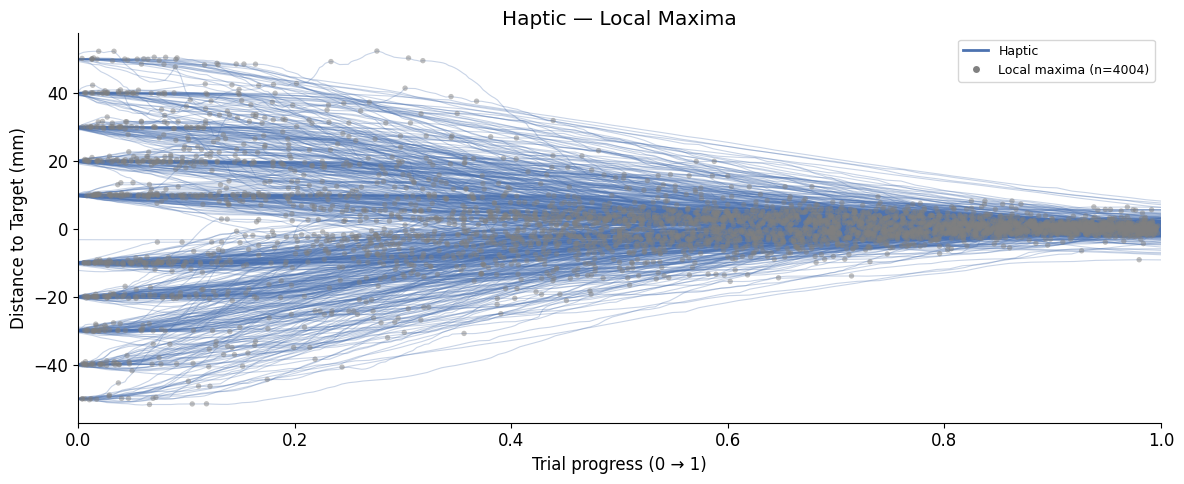

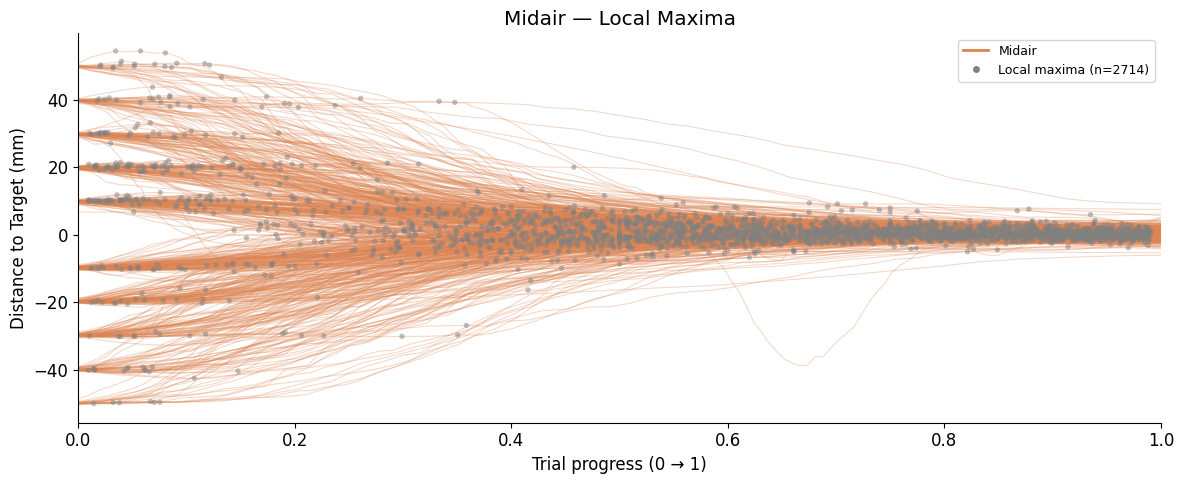

In [103]:
def plot_trajectory_progress(condition=None, participant_id=None, trial_numbers=None,
                             figsize=(12, 5), alpha=0.3, title=None,
                             show_local_maxima=True, marker_size=15, marker_alpha=0.5):
    """
    Plot DistanceToTarget(mm) vs normalised progress (0‑1) for selected trajectories,
    with optional local-maxima markers (the peaks counted by NLM).

    Parameters
    ----------
    show_local_maxima : bool
        If True, overlay scatter points at every local maximum.
    marker_size, marker_alpha : float
        Size and transparency of the local-maxima markers.
    (other parameters same as plot_trajectory)
    """
    subset = cont_data.copy()

    if condition is not None:
        if isinstance(condition, str):
            condition = [condition]
        subset = subset[subset['Condition'].isin(condition)]
    if participant_id is not None:
        if isinstance(participant_id, (int, np.integer)):
            participant_id = [participant_id]
        subset = subset[subset['ParticipantID'].isin(participant_id)]
    if trial_numbers is not None:
        if isinstance(trial_numbers, (int, np.integer)):
            trial_numbers = [trial_numbers]
        subset = subset[subset['TrialNumber'].isin(trial_numbers)]

    if subset.empty:
        print('No data matches the given filters.')
        return

    fig, ax = plt.subplots(figsize=figsize)
    groups = subset.groupby(['Condition', 'ParticipantID', 'TrialNumber'])
    n_groups = len(groups)
    total_maxima = 0

    for idx, ((cond, pid, trial), grp) in enumerate(groups):
        dist = grp['DistanceToTarget(mm)'].values
        n = len(dist)
        if n < 2:
            continue
        progress = np.linspace(0, 1, n)
        color = COLORS.get(cond, plt.cm.tab10(idx / max(n_groups - 1, 1)))
        ax.plot(progress, dist, color=color, alpha=alpha, linewidth=0.8)

        # overlay local maxima
        if show_local_maxima and n >= 3:
            lm_idx = [i for i in range(1, n - 1)
                      if dist[i] > dist[i - 1] and dist[i] > dist[i + 1]]
            if lm_idx:
                total_maxima += len(lm_idx)
                ax.scatter(progress[lm_idx], dist[lm_idx],
                           color='grey', s=marker_size, alpha=marker_alpha,
                           edgecolors='none', zorder=3)

    # Legend by condition (+ maxima marker)
    from matplotlib.lines import Line2D
    conds_present = subset['Condition'].unique()
    handles = [Line2D([0], [0], color=COLORS.get(c, 'grey'), lw=2, label=c.capitalize())
               for c in conds_present]
    if show_local_maxima:
        handles.append(Line2D([0], [0], marker='o', color='w', markerfacecolor='grey',
                              markersize=6, label=f'Local maxima (n={total_maxima})'))
    ax.legend(handles=handles, fontsize=9)

    ax.set_xlabel('Trial progress (0 → 1)')
    ax.set_ylabel('Distance to Target (mm)')
    ax.set_xlim(0, 1)
    ax.set_title(title or f'All trajectories by progress ({n_groups} trials)')
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()

# ---------- All trials with local maxima ----------
plot_trajectory_progress(title='All Trajectories — with Local Maxima')

# ---------- Per condition ----------
plot_trajectory_progress(condition='haptic', title='Haptic — Local Maxima')
plot_trajectory_progress(condition='midair', title='Midair — Local Maxima')